In [1]:
import pandas as pd
import numpy as np

In [2]:
path_db='../churn_db/analytics_data.csv'
df=pd.read_csv(path_db)

In [3]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            50000 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           50000 non-null  float64
 7   Pages_Per_Session              50000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 50000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       50000 non-null 

## Feature Selection (Features to keep)
Age, Gender ,Country, Membership_Years, Cart_Abandonment_Rate, Days_Since_Last_Purchase, Customer_Service_Calls(Most imp), Email_Open_Rate(Imp), Lifetime_Value

In [5]:
df.skew(numeric_only=True)

Age                               0.234380
Membership_Years                  1.136922
Login_Frequency                   0.511945
Session_Duration_Avg              0.431393
Pages_Per_Session                 0.419215
Cart_Abandonment_Rate            -0.263285
Wishlist_Items                    1.007118
Total_Purchases                   2.727305
Average_Order_Value              42.363862
Days_Since_Last_Purchase          2.090718
Discount_Usage_Rate               0.400959
Returns_Rate                      6.185957
Email_Open_Rate                   0.519931
Customer_Service_Calls            0.444784
Product_Reviews_Written           1.143134
Social_Media_Engagement_Score     0.570295
Mobile_App_Usage                  0.452248
Payment_Method_Diversity          0.665228
Lifetime_Value                    1.447403
Credit_Balance                    0.420480
Churned                           0.930983
dtype: float64

In [6]:
df['Churned'].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

In [7]:
X = df[['Age', 'Gender', 'Country', 'Membership_Years',
        'Cart_Abandonment_Rate', 'Days_Since_Last_Purchase',
        'Customer_Service_Calls', 'Email_Open_Rate',
        'Lifetime_Value']]

y = df['Churned']

In [8]:
num_cols=['Age', 'Membership_Years',
        'Cart_Abandonment_Rate', 'Days_Since_Last_Purchase',
        'Customer_Service_Calls', 'Email_Open_Rate',
        'Lifetime_Value']
cat_cols=[ 'Gender', 'Country']

In [9]:
#Numerical Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline= Pipeline(
    steps=[('scaler',StandardScaler())]
)

In [10]:
#categorical pipeline
from sklearn.preprocessing import OneHotEncoder
cat_pipeline= Pipeline(
    steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))]
)

In [11]:
#compbine using column Transformer
#Note, not used simple imputer cuz null value already handled in eda file
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

## Choosing Model

Our target variable is not (not churn/ churn) (0/1), which is binary classification

Models that can theoritically work are: Logistic regression and tree based model

However logistic regression wont work better in such complex data, still we will use it to show case

As for tree based model we will use models like Decision Tree, Random Forest Tree, Gradient Boosting and XG boost

In [12]:
from sklearn.model_selection import train_test_split

#stratify split, cuz we have imbalance target variable
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models={
    'logistic': LogisticRegression(),
    'rf' : RandomForestClassifier(),
    'dt' : DecisionTreeClassifier(),
    'xg' : XGBClassifier(eval_metric='logloss')
}


In [14]:
from sklearn.model_selection import cross_val_score
#Roc-AUC is good to check Imbalance dataset
for name,model in models.items():
    pipe=Pipeline(
        [
            ('processing', preprocessor),
            ('model', model)
        ]
    )
    score = cross_val_score(pipe,X_train,y_train,cv=5,scoring='roc_auc')
    print(name, score.mean())

logistic 0.7762784913543477


rf 0.8978264126139409


dt 0.7570431771616564


xg 0.8973131530472701


## Default model results

Clearly Random Forest and XGBoost are giving good results
We will take Random Forest model moving forward

**NOTE**: You may notice that the dataset was skewed and wasnt fixed using logTransformation or Box-Cox, Since we are mostly using tree based model, it ignores skewness, Incase of liner/logistic/SVM/distance based model ik needs to be checks.

In [15]:
rf_pipe=Pipeline(
        [
            ('processing', preprocessor),
            ('model', RandomForestClassifier(class_weight='balanced'))
        ]
    )

In [16]:

from sklearn.model_selection import GridSearchCV

param_grid={
    'model__n_estimators':[500], #More tree--> better but slower
    'model__max_depth' :[10,20], #contorl overfitting
    'model__min_samples_leaf':[1,3], #regularization
    'model__max_features' : [0.5] #Diversity among tree
}


In [17]:

grid=GridSearchCV(rf_pipe,param_grid,cv=3,scoring='roc_auc', n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)


{'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__n_estimators': 500}
0.9014738278794218


In [18]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred=grid.predict(X_test)
y_prob=grid.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.86      0.88      7110
           1       0.69      0.79      0.74      2890

    accuracy                           0.84     10000
   macro avg       0.80      0.82      0.81     10000
weighted avg       0.85      0.84      0.84     10000

ROC AUC: 0.898039848354333


# Discussion

## HyperParameter Tunning:1
'model__max_depth': 10

'model__max_features': 0.5

'model__min_samples_leaf': 4

'model__n_estimators': 500

Threshold =0.5

Current ROC-AUC goves good score but there is a problem, recall 

0.96 ->Out of all actual non-churned users, model correctly identified 96%

0.64 -->Out of all actual churned users, model correctly identified 64%

Precision: 0.86

Recall:    0.64

F1:        0.73

ROC-AUC:   0.8956

## Hyperparameter Tuning:2
Threshold=0.5

Used class_weight='balanced'

0.85 -> Out of all actual non-churned users, model correctly identified 85%

0.79 -> Out of all actual churned users, model correctly identified 79%

Precision: 0.68

Recall:    0.79

F1:        0.73

In [19]:
grid=GridSearchCV(rf_pipe,param_grid,cv=3,scoring='average_precision', n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__n_estimators': 500}
0.8523532731605753


In [20]:
from sklearn.metrics import average_precision_score
# PR-AUC is more informative than ROC-AUC since churners are minority class.
y_prob=grid.predict_proba(X_test)[:,1]
y_pred=(y_prob > 0.35).astype(int)

print(classification_report(y_test, y_pred))
pr_auc = average_precision_score(y_test, y_prob)
print(f"PR-AUC: {pr_auc:.4f}")
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85      7110
           1       0.62      0.87      0.72      2890

    accuracy                           0.81     10000
   macro avg       0.78      0.83      0.79     10000
weighted avg       0.84      0.81      0.82     10000

PR-AUC: 0.8497
ROC AUC: 0.8980202843112921


## Hyper Tuning 3:

This 3rd model (the way model makes decision is Hyper agressive towards finding users having high chances to get churned)



# Conclusion for Model training and evaluation.

We ended up with a single model that follows 3 different decision making

1. **Conservative churn detector**:Few false alarms ,Misses many churners | Good when:
Retention campaigns are expensive
You only want high-confidence churn cases
2. **Balanced**: Good general-purpose choice.
3. **Aggressive churn detector**: Aggressively finds user, not caring much of false alarm

Each of them should be used based on the final goal

In [21]:
best_rf = grid.best_estimator_
best_rf

,steps,"[('processing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
preprocessor = best_rf.named_steps["processing"]

rf_model = best_rf.named_steps["model"]

In [23]:
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)
X_test_shap.head()

,num__Age,num__Membership_Years,num__Cart_Abandonment_Rate,num__Days_Since_Last_Purchase,num__Customer_Service_Calls,num__Email_Open_Rate,num__Lifetime_Value,cat__Gender_Female,cat__Gender_Male,cat__Gender_Other,cat__Country_Australia,cat__Country_Canada,cat__Country_France,cat__Country_Germany,cat__Country_India,cat__Country_Japan,cat__Country_UK,cat__Country_USA
0,1.093633,0.833204,-1.855517,-0.147294,-1.377246,1.642797,1.483390,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.824818,0.105160,1.875005,-0.492091,0.121023,-0.998059,-0.815396,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.877676,-0.477275,0.512874,0.542301,0.495590,-1.062998,-1.021527,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.250441,0.105160,-0.395214,-0.492091,0.870157,-0.449685,-0.108856,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.429651,-0.331666,1.206211,-0.974808,0.121023,-1.503141,-1.112912,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [24]:
import shap

explainer = shap.TreeExplainer(rf_model)

In [25]:
shap_values = explainer.shap_values(X_test_shap)

In [26]:
type(shap_values)

numpy.ndarray

In [30]:
churn_shap_values = shap_values[:,:,1] #(sample,feature,class)

In [31]:
print(shap_values.shape)
print(X_test_shap.shape)

(10000, 18, 2)
(10000, 18)


In [33]:
print(churn_shap_values.shape)
print(X_test_shap.shape)

(10000, 18)
(10000, 18)


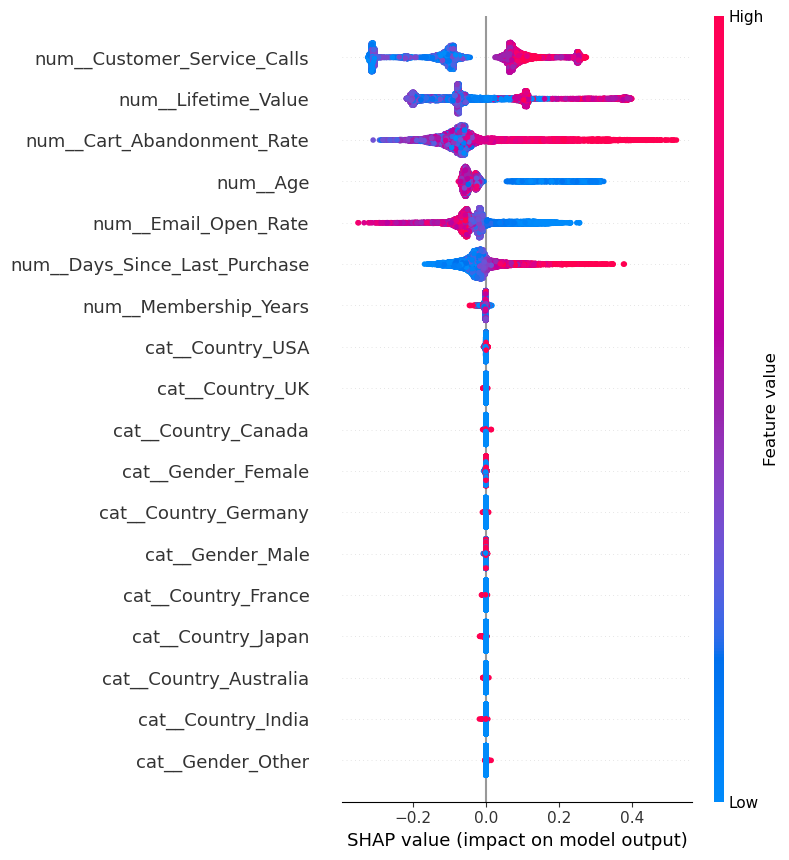

In [32]:
shap.summary_plot(
    churn_shap_values,
    X_test_shap
)

## Summary_plot , also called as Beeswarm plot

Shap value -> log(odds)

Log(odds) which increases/decreases wrt probablility

So right of the line is churn=1 and right of the line is churn=0

The color of point(each row) represent value of that feature

Ex: Customer_Service_call: 

IF high(red) ->chur=1 | IF low(blue) -> churn=0

## It explains Top features & shows how it determines if customer will churn 

**Note: This shap is done on the 3rd model, Aggressive churn detector.**

## Make a .pkl of the 3rd model

In [34]:
import joblib
joblib.dump(best_rf,'churn_model.pkl')

['churn_model.pkl']